# What Drives User Satisfaction in Fitness Apps?
## 1.A Google Play Health & Fitness App Analysis

### Project Aim
This notebook investigates which app characteristics and user-mentioned themes are associated with higher ratings in Google Play Health & Fitness apps.

### Target Users
Fitness app product managers and developers.

### Research Questions
1. What app characteristics are associated with higher ratings?
2. What themes appear most often in positive reviews?

## 2.Data Sources
This project uses publicly available datasets from Kaggle:
- Google Play Store app metadata
- Google Play user reviews

The datasets were selected because they provide both structured app information and user feedback text, which are suitable for analyzing user satisfaction.

## 3. Import Libraries
This section imports the Python libraries used for data cleaning, analysis, and visualisation.

In [2]:
# Data handling
import pandas as pd
import numpy as np

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Text processing
import re
from collections import Counter

# Optional settings
import warnings
warnings.filterwarnings("ignore")

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

## 4. Data Loading
This section loads the Google Play Store app metadata dataset and the user review dataset, then inspects their structure and key variables.

In [4]:
# Load datasets
apps_df = pd.read_csv("googleplaystore.csv")
reviews_df = pd.read_csv("googleplaystore_user_reviews.csv")

# Preview the first 5 rows
print("Apps dataset:")
display(apps_df.head())

print("Reviews dataset:")
display(reviews_df.head())

Apps dataset:


,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


Reviews dataset:


,App,Translated_Review,Sentiment,Sentiment_Polarity,Sentiment_Subjectivity
0,10 Best Foods for You,I like eat delicious food. That's I'm cooking ...,Positive,1.00,0.533333
1,10 Best Foods for You,This help eating healthy exercise regular basis,Positive,0.25,0.288462
2,10 Best Foods for You,NaN,NaN,NaN,NaN
3,10 Best Foods for You,Works great especially going grocery store,Positive,0.40,0.875000
4,10 Best Foods for You,Best idea us,Positive,1.00,0.300000


In [5]:
# Check dataset shape
print("Apps dataset shape:", apps_df.shape)
print("Reviews dataset shape:", reviews_df.shape)

# Check column names
print("Apps columns:")
print(apps_df.columns)

print("\nReviews columns:")
print(reviews_df.columns)

Apps dataset shape: (10841, 13)
Reviews dataset shape: (64295, 5)
Apps columns:
Index(['App', 'Category', 'Rating', 'Reviews', 'Size', 'Installs', 'Type',
       'Price', 'Content Rating', 'Genres', 'Last Updated', 'Current Ver',
       'Android Ver'],
      dtype='object')

Reviews columns:
Index(['App', 'Translated_Review', 'Sentiment', 'Sentiment_Polarity',
       'Sentiment_Subjectivity'],
      dtype='object')


In [6]:
# Check missing values
print("Missing values in apps dataset:")
print(apps_df.isnull().sum())

print("\nMissing values in reviews dataset:")
print(reviews_df.isnull().sum())

Missing values in apps dataset:
App                  0
Category             0
Rating            1474
Reviews              0
Size                 0
Installs             0
Type                 1
Price                0
Content Rating       1
Genres               0
Last Updated         0
Current Ver          8
Android Ver          3
dtype: int64

Missing values in reviews dataset:
App                           0
Translated_Review         26868
Sentiment                 26863
Sentiment_Polarity        26863
Sentiment_Subjectivity    26863
dtype: int64


## 5. Data Cleaning and Preparation

### 5.1 Filter Health & Fitness Apps
This section filters the app dataset to keep only apps in the Health & Fitness category, which is the focus of this project.

In [7]:
# Check unique categories first
apps_df["Category"].unique()

array(['ART_AND_DESIGN', 'AUTO_AND_VEHICLES', 'BEAUTY',
       'BOOKS_AND_REFERENCE', 'BUSINESS', 'COMICS', 'COMMUNICATION',
       'DATING', 'EDUCATION', 'ENTERTAINMENT', 'EVENTS', 'FINANCE',
       'FOOD_AND_DRINK', 'HEALTH_AND_FITNESS', 'HOUSE_AND_HOME',
       'LIBRARIES_AND_DEMO', 'LIFESTYLE', 'GAME', 'FAMILY', 'MEDICAL',
       'SOCIAL', 'SHOPPING', 'PHOTOGRAPHY', 'SPORTS', 'TRAVEL_AND_LOCAL',
       'TOOLS', 'PERSONALIZATION', 'PRODUCTIVITY', 'PARENTING', 'WEATHER',
       'VIDEO_PLAYERS', 'NEWS_AND_MAGAZINES', 'MAPS_AND_NAVIGATION',
       '1.9'], dtype=object)

In [26]:
fitness_apps_df = apps_df[apps_df["Category"] == "HEALTH_AND_FITNESS"].copy()

print("Filtered dataset shape:", fitness_apps_df.shape)
display(fitness_apps_df.head())

Filtered dataset shape: (341, 13)


,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
1256,Home Workout - No Equipment,HEALTH_AND_FITNESS,4.8,428156,15M,"10,000,000+",Free,0,Everyone,Health & Fitness,"June 28, 2018",Varies with device,Varies with device
1257,Step Counter - Calorie Counter,HEALTH_AND_FITNESS,4.0,1577,2.2M,"500,000+",Free,0,Everyone,Health & Fitness,"August 12, 2017",1.0.7,4.4 and up
1258,Lose Belly Fat in 30 Days - Flat Stomach,HEALTH_AND_FITNESS,4.9,38098,11M,"5,000,000+",Free,0,Everyone,Health & Fitness,"June 21, 2018",1.0.4,4.2 and up
1259,Pedometer - Step Counter Free & Calorie Burner,HEALTH_AND_FITNESS,4.8,31139,6.9M,"1,000,000+",Free,0,Everyone,Health & Fitness,"July 24, 2018",1.0.11,4.1 and up
1260,Six Pack in 30 Days - Abs Workout,HEALTH_AND_FITNESS,4.9,272337,13M,"10,000,000+",Free,0,Everyone,Health & Fitness,"June 21, 2018",1.0.2,4.2 and up


After filtering, only Health & Fitness apps are retained for analysis. This makes the analysis more relevant to the target users, who are fitness app product managers and developers.

### 5.2 Clean Key Variables
This section cleans key variables used in the analysis, including rating, reviews, installs, type, and price.

In [27]:
fitness_apps_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 341 entries, 1256 to 10760
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             341 non-null    object 
 1   Category        341 non-null    object 
 2   Rating          297 non-null    float64
 3   Reviews         341 non-null    object 
 4   Size            341 non-null    object 
 5   Installs        341 non-null    object 
 6   Type            341 non-null    object 
 7   Price           341 non-null    object 
 8   Content Rating  341 non-null    object 
 9   Genres          341 non-null    object 
 10  Last Updated    341 non-null    object 
 11  Current Ver     341 non-null    object 
 12  Android Ver     341 non-null    object 
dtypes: float64(1), object(12)
memory usage: 37.3+ KB


In [28]:
# Convert Rating to numeric
fitness_apps_df["Rating"] = pd.to_numeric(fitness_apps_df["Rating"], errors="coerce")

In [29]:
# Convert Reviews to numeric
fitness_apps_df["Reviews"] = pd.to_numeric(fitness_apps_df["Reviews"], errors="coerce")

In [30]:
# Clean Installs column
fitness_apps_df["Installs"] = (
    fitness_apps_df["Installs"]
    .astype(str)
    .str.replace(",", "", regex=False)
    .str.replace("+", "", regex=False)
)

fitness_apps_df["Installs"] = pd.to_numeric(fitness_apps_df["Installs"], errors="coerce")

In [31]:
# Clean Price column
fitness_apps_df["Price"] = (
    fitness_apps_df["Price"]
    .astype(str)
    .str.replace("$", "", regex=False)
)

fitness_apps_df["Price"] = pd.to_numeric(fitness_apps_df["Price"], errors="coerce")

In [32]:
fitness_apps_df[["Rating", "Reviews", "Installs", "Price", "Type"]].head()

,Rating,Reviews,Installs,Price,Type
1256,4.8,428156,10000000,0.0,Free
1257,4.0,1577,500000,0.0,Free
1258,4.9,38098,5000000,0.0,Free
1259,4.8,31139,1000000,0.0,Free
1260,4.9,272337,10000000,0.0,Free


### 5.3 Handle Missing Values and Duplicates
This section removes duplicated records and handles missing values in important variables.

In [42]:
# Check duplicates
print("Number of duplicated rows:", fitness_apps_df.duplicated().sum())

Number of duplicated rows: 0


In [43]:
# Remove duplicates
fitness_apps_df = fitness_apps_df.drop_duplicates()
print("Shape after removing duplicates:", fitness_apps_df.shape)

Shape after removing duplicates: (306, 13)


In [44]:
# Check missing values in key columns
print(fitness_apps_df[["Rating", "Reviews", "Installs", "Price", "Type"]].isnull().sum())

Rating      44
Reviews      0
Installs     0
Price        0
Type         0
dtype: int64


In [45]:
# Drop rows with missing Rating
fitness_apps_df = fitness_apps_df.dropna(subset=["Rating"])
print("Shape after dropping missing ratings:", fitness_apps_df.shape)

Shape after dropping missing ratings: (262, 13)


### 5.4 Prepare Review Data
This section prepares the user review dataset for text-based analysis by removing missing reviews and keeping relevant fields.

In [46]:
reviews_df.head()
reviews_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64295 entries, 0 to 64294
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   App                     64295 non-null  object 
 1   Translated_Review       37427 non-null  object 
 2   Sentiment               37432 non-null  object 
 3   Sentiment_Polarity      37432 non-null  float64
 4   Sentiment_Subjectivity  37432 non-null  float64
dtypes: float64(2), object(3)
memory usage: 2.5+ MB


In [47]:
# Remove missing review text
reviews_clean_df = reviews_df.dropna(subset=["Translated_Review"]).copy()

print("Clean review dataset shape:", reviews_clean_df.shape)
display(reviews_clean_df.head())

Clean review dataset shape: (37427, 5)


,App,Translated_Review,Sentiment,Sentiment_Polarity,Sentiment_Subjectivity
0,10 Best Foods for You,I like eat delicious food. That's I'm cooking ...,Positive,1.00,0.533333
1,10 Best Foods for You,This help eating healthy exercise regular basis,Positive,0.25,0.288462
3,10 Best Foods for You,Works great especially going grocery store,Positive,0.40,0.875000
4,10 Best Foods for You,Best idea us,Positive,1.00,0.300000
5,10 Best Foods for You,Best way,Positive,1.00,0.300000


In [48]:
# Check sentiment distribution
print(reviews_clean_df["Sentiment"].value_counts())

Sentiment
Positive    23998
Negative     8271
Neutral      5158
Name: count, dtype: int64


In [49]:
# Check app name columns
print("Apps dataset column names:", fitness_apps_df.columns)
print("Reviews dataset column names:", reviews_clean_df.columns)

Apps dataset column names: Index(['App', 'Category', 'Rating', 'Reviews', 'Size', 'Installs', 'Type',
       'Price', 'Content Rating', 'Genres', 'Last Updated', 'Current Ver',
       'Android Ver'],
      dtype='object')
Reviews dataset column names: Index(['App', 'Translated_Review', 'Sentiment', 'Sentiment_Polarity',
       'Sentiment_Subjectivity'],
      dtype='object')


## 6. Descriptive Analysis

This section provides an overview of the Health & Fitness apps in the dataset. It examines the general distribution of ratings, installs, app type, review volume, and pricing structure.

The purpose of this section is to understand the overall market patterns before exploring which characteristics may be associated with higher user satisfaction.

### 6.1 Summary Statistics

This subsection presents summary statistics for key variables, including rating, reviews, installs, and price. These statistics provide a general understanding of the dataset before visual analysis.

In [50]:
# Select key numerical columns
summary_stats = fitness_apps_df[["Rating", "Reviews", "Installs", "Price"]].describe()

display(summary_stats)

,Rating,Reviews,Installs,Price
count,262.000000,2.620000e+02,2.620000e+02,262.000000
mean,4.261450,1.177293e+05,5.194680e+06,0.161794
std,0.650613,3.708912e+05,3.187442e+07,0.869982
min,1.400000,1.000000e+00,1.000000e+01,0.000000
25%,4.100000,5.060000e+02,5.000000e+04,0.000000
50%,4.500000,1.236700e+04,5.000000e+05,0.000000
75%,4.600000,7.126825e+04,5.000000e+06,0.000000
max,5.000000,4.559407e+06,5.000000e+08,7.990000


### 6.2 Distribution of App Ratings

This chart shows how ratings are distributed across Health & Fitness apps. It helps identify whether most apps receive relatively high ratings or whether ratings vary widely across the category.

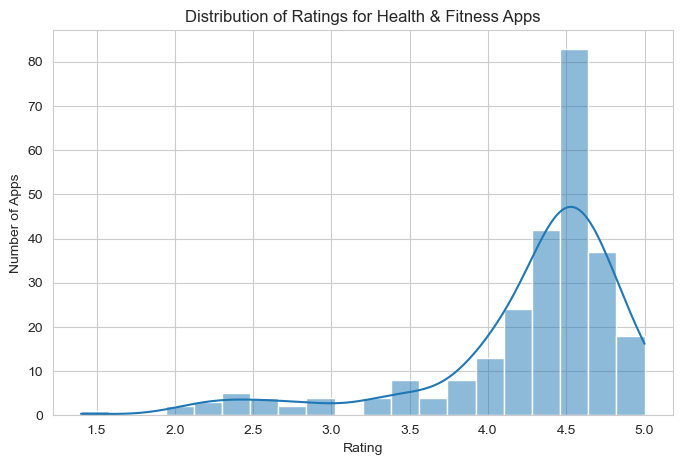

In [51]:
plt.figure(figsize=(8,5))
sns.histplot(fitness_apps_df["Rating"], bins=20, kde=True)
plt.title("Distribution of Ratings for Health & Fitness Apps")
plt.xlabel("Rating")
plt.ylabel("Number of Apps")
plt.show()

The rating distribution helps show the general satisfaction level in the category. If the ratings are concentrated at the higher end, this may suggest that many apps receive relatively positive user evaluations.

### 6.3 Distribution of Install Counts

This chart examines the distribution of install counts across Health & Fitness apps. Since install counts are often highly skewed, a logarithmic scale is used for clearer interpretation.

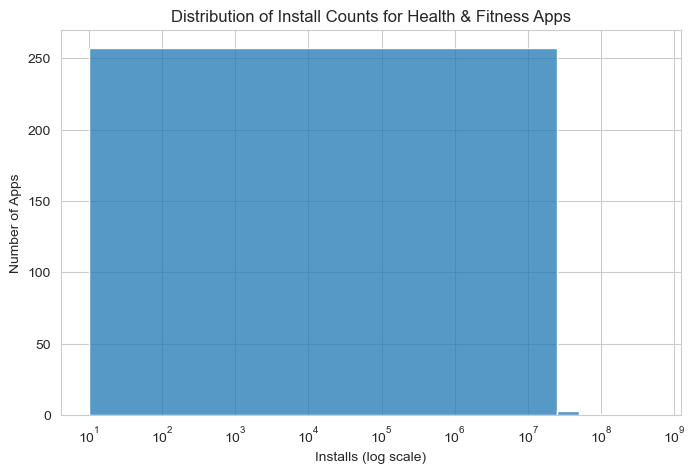

In [52]:
plt.figure(figsize=(8,5))
sns.histplot(fitness_apps_df["Installs"], bins=20)
plt.xscale("log")
plt.title("Distribution of Install Counts for Health & Fitness Apps")
plt.xlabel("Installs (log scale)")
plt.ylabel("Number of Apps")
plt.show()

Install counts can indicate app popularity and market reach. A highly skewed distribution would suggest that only a small number of apps attract very large user bases.

### 6.4 App Type Composition

This chart compares the number of free and paid apps in the Health & Fitness category. It provides a basic overview of the pricing structure in the dataset.

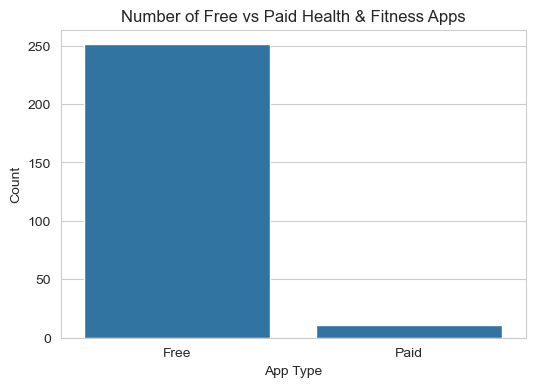

In [53]:
plt.figure(figsize=(6,4))
sns.countplot(data=fitness_apps_df, x="Type")
plt.title("Number of Free vs Paid Health & Fitness Apps")
plt.xlabel("App Type")
plt.ylabel("Count")
plt.show()

This comparison shows whether the category is dominated by free apps or whether paid apps make up a meaningful share of the market.

### 6.5 Average Rating by App Type

This chart compares the average rating of free and paid Health & Fitness apps. It provides an initial descriptive comparison between the two pricing models.

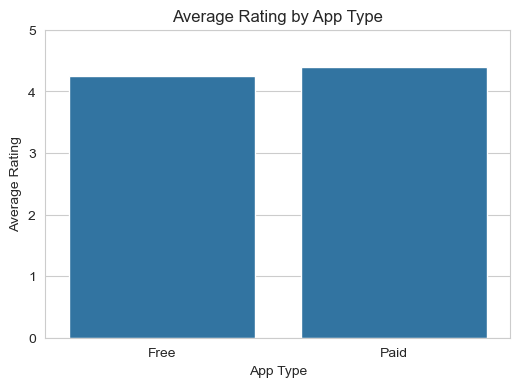

,Type,Rating
0,Free,4.255777
1,Paid,4.390909


In [54]:
avg_rating_by_type = fitness_apps_df.groupby("Type")["Rating"].mean().reset_index()

plt.figure(figsize=(6,4))
sns.barplot(data=avg_rating_by_type, x="Type", y="Rating")
plt.title("Average Rating by App Type")
plt.xlabel("App Type")
plt.ylabel("Average Rating")
plt.ylim(0, 5)
plt.show()

display(avg_rating_by_type)

This comparison provides an initial indication of whether free and paid apps differ in average user satisfaction. However, descriptive analysis alone does not imply causation.

## 7. Research Question 1: App Characteristics and Ratings

This section investigates whether selected app characteristics are associated with higher user ratings among Health & Fitness apps on Google Play.

The purpose is to identify basic product-related patterns that may help fitness app product managers and developers better understand what kinds of apps tend to receive stronger user evaluations.

### 7.1 Prepare Data for Analysis

This subsection prepares the variables required for Research Question 1, including rating, installs, reviews, type, and price.

In [57]:
rq1_df = fitness_apps_df[["App", "Rating", "Installs", "Reviews", "Type", "Price"]].copy()

# Keep rows with valid values in key variables
rq1_df = rq1_df.dropna(subset=["Rating", "Installs", "Reviews", "Type", "Price"])

print("RQ1 dataset shape:", rq1_df.shape)
display(rq1_df.head())

RQ1 dataset shape: (262, 6)


,App,Rating,Installs,Reviews,Type,Price
1256,Home Workout - No Equipment,4.8,10000000,428156,Free,0.0
1257,Step Counter - Calorie Counter,4.0,500000,1577,Free,0.0
1258,Lose Belly Fat in 30 Days - Flat Stomach,4.9,5000000,38098,Free,0.0
1259,Pedometer - Step Counter Free & Calorie Burner,4.8,1000000,31139,Free,0.0
1260,Six Pack in 30 Days - Abs Workout,4.9,10000000,272337,Free,0.0


### 7.2 Do Free and Paid Apps Have Different Ratings?

This chart compares ratings between free and paid Health & Fitness apps. It provides a simple first look at whether app monetisation type is associated with user satisfaction.

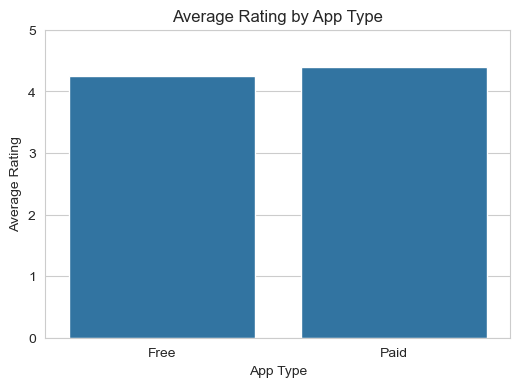

,Type,Rating
0,Free,4.255777
1,Paid,4.390909


In [59]:
avg_rating_type = rq1_df.groupby("Type")["Rating"].mean().reset_index()

plt.figure(figsize=(6,4))
sns.barplot(data=avg_rating_type, x="Type", y="Rating")
plt.title("Average Rating by App Type")
plt.xlabel("App Type")
plt.ylabel("Average Rating")
plt.ylim(0, 5)
plt.show()

display(avg_rating_type)

The comparison shows whether free and paid apps differ in their overall rating levels. This may provide an initial indication of whether pricing model is linked to user satisfaction, although it does not imply a causal relationship.

### 7.3 Are More Popular Apps Rated More Highly?

This chart explores the relationship between install counts and ratings. Install count is used here as a basic indicator of app popularity and market reach.

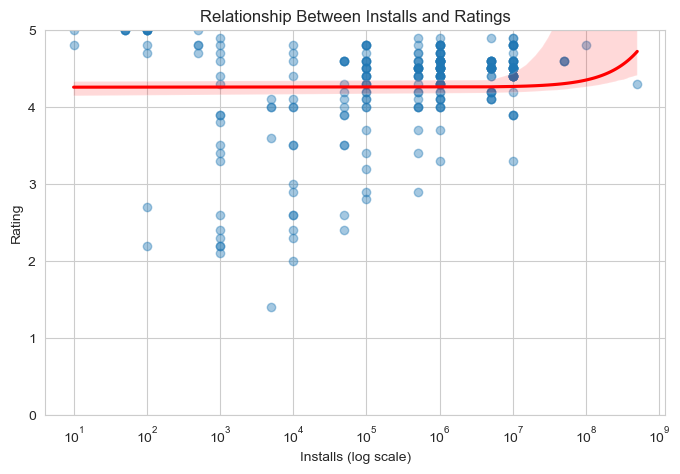

In [61]:
plt.figure(figsize=(8,5))
sns.regplot(data=rq1_df, x="Installs", y="Rating", scatter_kws={"alpha":0.4}, line_kws={"color":"red"})
plt.xscale("log")
plt.title("Relationship Between Installs and Ratings")
plt.xlabel("Installs (log scale)")
plt.ylabel("Rating")
plt.ylim(0, 5)
plt.show()

This chart helps assess whether more widely downloaded apps also tend to receive higher ratings. A positive pattern may suggest that highly adopted apps are also better received by users, although popularity and satisfaction are not the same concept.

### 7.4 Are Apps with More Reviews Rated More Highly?

This chart explores whether apps with larger numbers of user reviews tend to have different rating patterns.

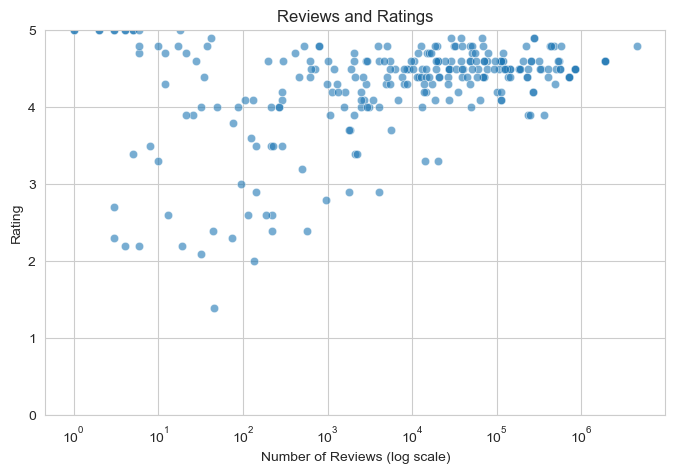

In [62]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=rq1_df, x="Reviews", y="Rating", alpha=0.6)
plt.xscale("log")
plt.title("Reviews and Ratings")
plt.xlabel("Number of Reviews (log scale)")
plt.ylabel("Rating")
plt.ylim(0, 5)
plt.show()

Review volume may reflect user engagement and app visibility. This analysis provides an initial view of whether more discussed apps also achieve stronger satisfaction scores.

### 7.5 Findings for Research Question 1

The analysis suggests that some app characteristics may be associated with rating differences among Health & Fitness apps. In particular, app type, install volume, and review volumeprovide useful descriptive signals for understanding user satisfaction patterns.

However, these results should be interpreted cautiously. They show association rather than causation, and ratings may also be influenced by factors not captured in the current dataset, such as app usability, feature design, update quality, and user expectations.

## 8. Research Question 2: User Review Themes and Positive/Negative Feedback

This section examines the themes that appear most frequently in positive and negative user reviews of Health & Fitness apps.

The purpose is to understand what users appreciate and complain about most, so that fitness app product managers and developers can identify possible drivers of user satisfaction and dissatisfaction.

### 8.1 Prepare Review Data

This subsection prepares the review dataset for text analysis by removing missing values and keeping relevant variables.

In [63]:
print(reviews_clean_df.columns)
display(reviews_clean_df.head())

Index(['App', 'Translated_Review', 'Sentiment', 'Sentiment_Polarity',
       'Sentiment_Subjectivity'],
      dtype='object')


,App,Translated_Review,Sentiment,Sentiment_Polarity,Sentiment_Subjectivity
0,10 Best Foods for You,I like eat delicious food. That's I'm cooking ...,Positive,1.00,0.533333
1,10 Best Foods for You,This help eating healthy exercise regular basis,Positive,0.25,0.288462
3,10 Best Foods for You,Works great especially going grocery store,Positive,0.40,0.875000
4,10 Best Foods for You,Best idea us,Positive,1.00,0.300000
5,10 Best Foods for You,Best way,Positive,1.00,0.300000


In [64]:
rq2_reviews_df = reviews_clean_df[["App", "Translated_Review", "Sentiment"]].copy()

# Remove missing values
rq2_reviews_df = rq2_reviews_df.dropna(subset=["Translated_Review", "Sentiment"])

print("RQ2 review dataset shape:", rq2_reviews_df.shape)
print(rq2_reviews_df["Sentiment"].value_counts())
display(rq2_reviews_df.head())

RQ2 review dataset shape: (37427, 3)
Sentiment
Positive    23998
Negative     8271
Neutral      5158
Name: count, dtype: int64


,App,Translated_Review,Sentiment
0,10 Best Foods for You,I like eat delicious food. That's I'm cooking ...,Positive
1,10 Best Foods for You,This help eating healthy exercise regular basis,Positive
3,10 Best Foods for You,Works great especially going grocery store,Positive
4,10 Best Foods for You,Best idea us,Positive
5,10 Best Foods for You,Best way,Positive


### 8.2 Keep Reviews for Health & Fitness Apps

This subsection keeps only the reviews associated with Health & Fitness apps in the filtered app dataset.

In [65]:
fitness_app_names = fitness_apps_df["App"].unique()

rq2_reviews_df = rq2_reviews_df[rq2_reviews_df["App"].isin(fitness_app_names)].copy()

print("Filtered review dataset shape:", rq2_reviews_df.shape)
print(rq2_reviews_df["Sentiment"].value_counts())

Filtered review dataset shape: (2249, 3)
Sentiment
Positive    1754
Negative     257
Neutral      238
Name: count, dtype: int64


### 8.3 Separate Positive and Negative Reviews

This subsection separates positive and negative reviews to compare the themes mentioned in each group.

In [66]:
positive_reviews = rq2_reviews_df[rq2_reviews_df["Sentiment"] == "Positive"].copy()
negative_reviews = rq2_reviews_df[rq2_reviews_df["Sentiment"] == "Negative"].copy()

print("Positive reviews:", positive_reviews.shape  [0])
print("Negative reviews:", negative_reviews.shape  [0])

Positive reviews: 1754
Negative reviews: 257


### 8.4 Most Frequent Words in Positive Reviews

This subsection identifies the most frequently mentioned words in positive reviews to understand what users value most.

In [82]:
positive_words = []
for words in positive_reviews["clean_words"]:
    positive_words.extend(words)

positive_word_counts = Counter(positive_words)
top_positive_words = positive_word_counts.most_common(15)

top_positive_words_df = pd.DataFrame(top_positive_words, columns=["Word", "Count"])
display(top_positive_words_df)


,Word,Count
0,great,457
1,app,408
2,good,368
3,love,351
4,like,336
5,food,291
6,really,224
7,easy,218
8,would,216
9,im,211


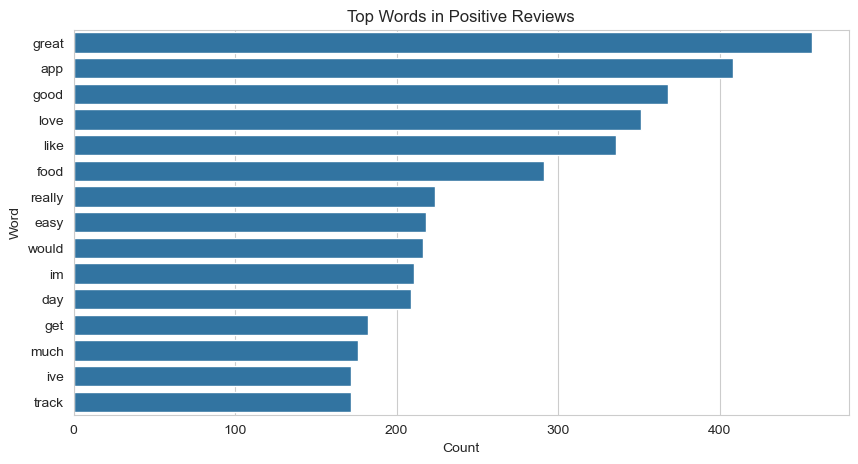

In [83]:
plt.figure(figsize=(10,5))
sns.barplot(data=top_positive_words_df, x="Count", y="Word")
plt.title("Top Words in Positive Reviews")
plt.xlabel("Count")
plt.ylabel("Word")
plt.show()

The most frequent words in positive reviews provide an initial indication of which product aspects users appreciate most, such as usability, helpfulness, or motivational value.

### 8.5 Most Frequent Words in Negative Reviews

This subsection identifies the most frequently mentioned words in negative reviews to understand the main sources of dissatisfaction.

In [77]:
negative_words = []
for words in negative_reviews["clean_words"]:
    negative_words.extend(words)

negative_word_counts = Counter(negative_words)
top_negative_words = negative_word_counts.most_common(15)

top_negative_words_df = pd.DataFrame(top_negative_words, columns=["Word", "Count"])
display(top_negative_words_df)

,Word,Count
0,app,52
1,even,51
2,time,43
3,like,42
4,get,42
5,phone,40
6,cant,39
7,log,35
8,ads,32
9,ive,30


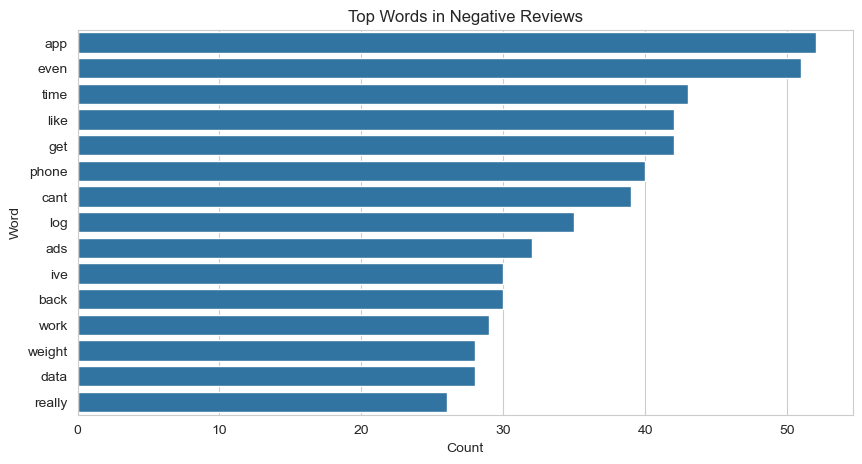

In [78]:
plt.figure(figsize=(10,5))
sns.barplot(data=top_negative_words_df, x="Count", y="Word")
plt.title("Top Words in Negative Reviews")
plt.xlabel("Count")
plt.ylabel("Word")
plt.show()

The most frequent words in negative reviews help highlight recurring pain points, such as technical problems, payment concerns, poor usability, or dissatisfaction with app features.

### 8.6 Findings for Research Question 2

The review analysis shows that positive and negative reviews highlight different aspects of user experience. Positive reviews tend to emphasise beneficial and enjoyable aspects of the apps, while negative reviews more often reveal frustrations such as technical issues, pricing concerns, or unmet expectations.

These findings are useful for fitness app product managers and developers because they provide direct user-level signals about what users value and what problems may reduce satisfaction.

## 9. Conclusion and Recommendations

This project explored which app characteristics and user review themes are associated with higher ratings among Health & Fitness apps on Google Play.

The results suggest that app type, popularity indicators, and review content may all provide useful signals for understanding user satisfaction. Positive and negative reviews highlighted different aspects of the app experience, which may help product managers and developers identify both strengths and improvement areas.

However, the analysis has limitations, including dataset age, category scope, and the simplicity of the text analysis. Future work could apply more advanced methods and more recent data to generate deeper insights.